In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [3]:
os.getcwd()

'g:\\Jatin course\\OWN DATA SCIENCE PROJECT\\SmartSale — ML-Based Retail Sales Forecasting & Inventory Recommendation System\\notebooks'

In [4]:
train = pd.read_csv("../data/raw/train.csv")

C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_20260\513577916.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


In [5]:
train

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [6]:
train.shape

(1017209, 9)

In [7]:
train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='str')

In [8]:
train.dtypes

Store             int64
DayOfWeek         int64
Date                str
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object

In [9]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [10]:
train.duplicated().sum()

np.int64(0)

In [11]:
pd.to_datetime(train["Date"]).min()

Timestamp('2013-01-01 00:00:00')

In [12]:
pd.to_datetime(train["Date"]).max()

Timestamp('2015-07-31 00:00:00')

In [13]:
train["Store"].nunique()

1115

In [14]:
train["Sales"].min()

np.int64(0)

In [15]:
train["Sales"].max()

np.int64(41551)

In [16]:
train["Sales"].mean()

np.float64(5773.818972305593)

In [17]:
(train["Sales"] == 0).sum()

np.int64(172871)

In [18]:
train["Open"].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [19]:
train.groupby("Open")["Sales"].mean()

Open
0       0.000000
1    6955.514291
Name: Sales, dtype: float64

In [20]:
train["Promo"].value_counts()

Promo
0    629129
1    388080
Name: count, dtype: int64

In [21]:
train.groupby("Promo")["Sales"].mean()

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

In [22]:
train["StateHoliday"].value_counts()

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [23]:
train["StateHoliday"].unique()

array(['0', 'a', 'b', 'c', 0], dtype=object)

In [24]:
train.groupby("StateHoliday")["Sales"].mean()

StateHoliday
0    5733.530624
0    5980.279717
a     290.735686
b     214.311510
c     168.733171
Name: Sales, dtype: float64

In [25]:
train[train["StateHoliday"] == "a"]["Open"].value_counts()

Open
0    19566
1      694
Name: count, dtype: int64

In [26]:
train[train["StateHoliday"] == "b"]["Open"].value_counts()

Open
0    6545
1     145
Name: count, dtype: int64

In [27]:
train[train["StateHoliday"] == "c"]["Open"].value_counts()

Open
0    4029
1      71
Name: count, dtype: int64

In [28]:
train["SchoolHoliday"].value_counts()

SchoolHoliday
0    835488
1    181721
Name: count, dtype: int64

In [29]:
train.groupby("SchoolHoliday")["Sales"].mean()

SchoolHoliday
0    5620.979034
1    6476.522207
Name: Sales, dtype: float64

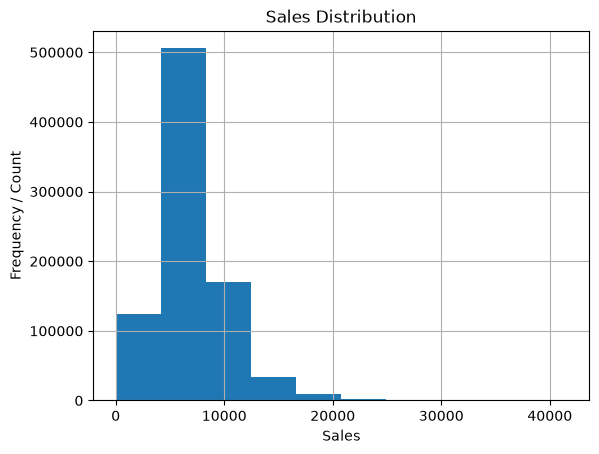

In [30]:
plt.hist(train[train["Open"] == 1]["Sales"])
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency / Count")
plt.grid(True)
plt.show()

Salesની મોટાભાગની values 0 થી 10,000ની આસપાસ છે. Sales distribution right-skewed છે, એટલે થોડા દિવસોમાં Sales ખૂબ વધારે જોવા મળે છે. Sales = 0 વાળા ઘણા records છે, જે મુખ્યત્વે stores બંધ હોવાને કારણે છે.

In [31]:
train["Date"] = pd.to_datetime( train["Date"] )

In [32]:
train.dtypes

Store                     int64
DayOfWeek                 int64
Date             datetime64[us]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object

In [33]:
daily_sales = train.groupby(["Date"])["Sales"].sum()

In [34]:
daily_sales.head()

Date
2013-01-01      97235
2013-01-02    6949829
2013-01-03    6347820
2013-01-04    6638954
2013-01-05    5951593
Name: Sales, dtype: int64

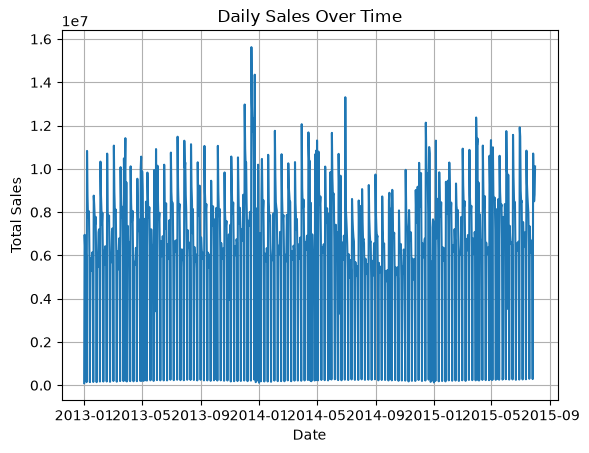

In [35]:
plt.plot( daily_sales.index, daily_sales.values )
plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

Daily Salesમાં દિવસ પ્રમાણે ઘણો ફેરફાર જોવા મળે છે. કેટલાક દિવસોમાં Sales ખૂબ ઓછી અને કેટલાક દિવસોમાં ખૂબ વધારે છે. 2013 થી 2015 દરમિયાન કોઈ સરળ સીધો trend દેખાતો નથી. આગળ weekly અને seasonal pattern તપાસવા જરૂરી છે.

In [36]:
train.groupby("DayOfWeek")["Sales"].mean()

DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64

અલગ-અલગ દિવસોમાં Average Sales અલગ છે. Monday (Day 1) નું average Sales સૌથી વધારે છે, જ્યારે Sunday (Day 7) નું ખૂબ ઓછું છે. Sundayની ઓછી Salesનું મુખ્ય કારણ ઘણા stores બંધ હોવું હોઈ શકે છે.

In [37]:
train.groupby("Promo")["Sales"].mean()

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

Promo = 0 → Average Sales ≈ 4,406   NO PROMOTIONS

Promo = 1 → Average Sales ≈ 7,991   PEOMOTIONS

~એટલે datasetમાં Promo વાળા દિવસોમાં average Sales વધારે જોવા મળે છે.

~પરંતુ આપણે એવું નથી કહેવાનું કે Promoના કારણે જ Sales વધી. આ માત્ર observed relationship છે; બીજા factors પણ અસર કરી શકે.

<BarContainer object of 2 artists>

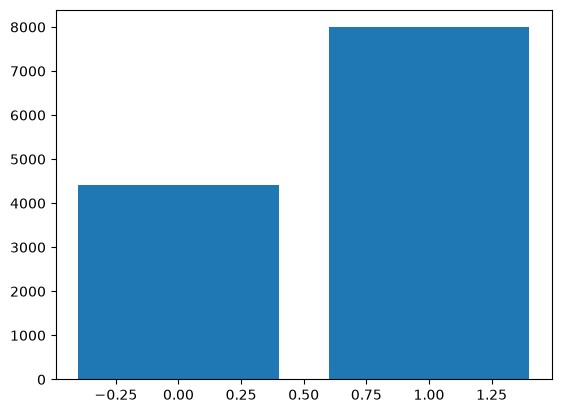

In [38]:
avg_sales_promo = train.groupby("Promo")["Sales"].mean()
plt.bar(avg_sales_promo.index ,avg_sales_promo.values)

Promo=1 વાળા દિવસોમાં Average Sales, Promo=0 કરતા વધારે જોવા મળે છે. જોકે આ માત્ર observed relationship છે; તેના પરથી Promo Sales વધારવાનું કારણ છે એવું સીધું કહી શકાય નહીં.”

groupby વગર પણ bar chart બનાવી શકાય, પરંતુ એક વાત મહત્વની છે:

Promo માં 0 અને 1 છે અને દરેક rowની Sales અલગ છે. જો તમે સીધું:

plt.bar(train["Promo"], train["Sales"])

કરશો તો લગભગ 10 લાખ bars બની જશે, એટલે graph useful નહીં રહે.

આપણે જે comparison કરવું છે — Promo 0 vs Promo 1 ની average Sales — તેના માટે groupby() યોગ્ય અને clean રીત છે.

In [39]:
avg_sales_day = train.groupby("DayOfWeek")["Sales"].mean()
avg_sales_day

DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64

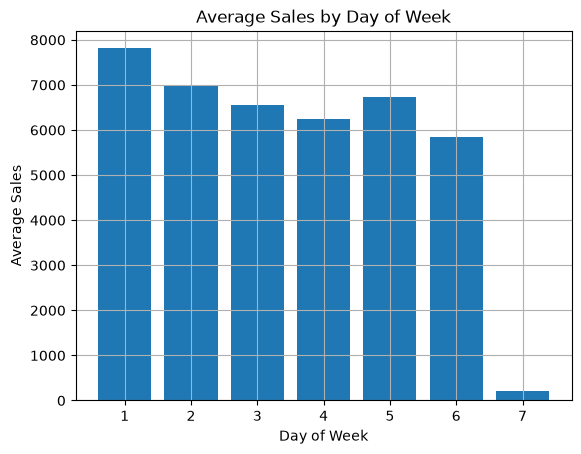

In [40]:
plt.bar(avg_sales_day.index,avg_sales_day.values)
plt.grid(True)
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.show()

“Average Sales અલગ-અલગ weekdays પ્રમાણે બદલાય છે. Mondayનું average Sales સૌથી વધારે છે, જ્યારે Sundayનું સૌથી ઓછું છે. Sundayના ઓછા Salesનું એક મહત્વનું કારણ stores બંધ હોવું હોઈ શકે છે.”

In [41]:
train.groupby("SchoolHoliday")["Sales"].mean()

SchoolHoliday
0    5620.979034
1    6476.522207
Name: Sales, dtype: float64

In [42]:
avg_sales_school = train.groupby("SchoolHoliday")["Sales"].mean()         

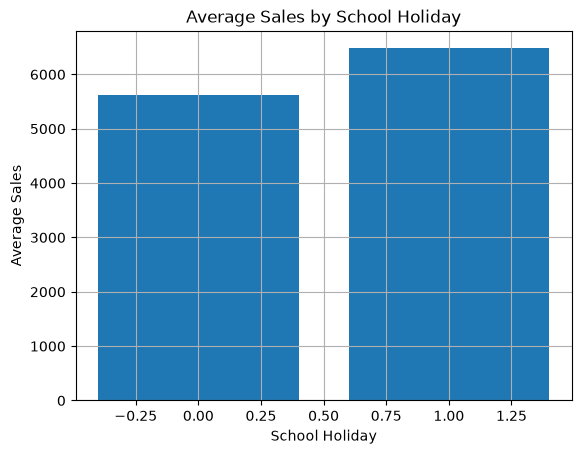

In [43]:
plt.bar(avg_sales_school.index, avg_sales_school.values)

plt.title("Average Sales by School Holiday")
plt.xlabel("School Holiday")
plt.ylabel("Average Sales")
plt.grid(True)

plt.show()

“SchoolHoliday વાળા દિવસોમાં Average Sales, non-SchoolHoliday દિવસો કરતા વધારે જોવા મળે છે. આ datasetમાં SchoolHoliday અને Sales વચ્ચે observed difference જોવા મળે છે, પરંતુ તે causation સાબિત કરતું નથી.”

In [44]:
train.groupby("Open")["Sales"].mean()

Open
0       0.000000
1    6955.514291
Name: Sales, dtype: float64

In [45]:
avg_sales_open = train.groupby("Open")["Sales"].mean()
avg_sales_open

Open
0       0.000000
1    6955.514291
Name: Sales, dtype: float64

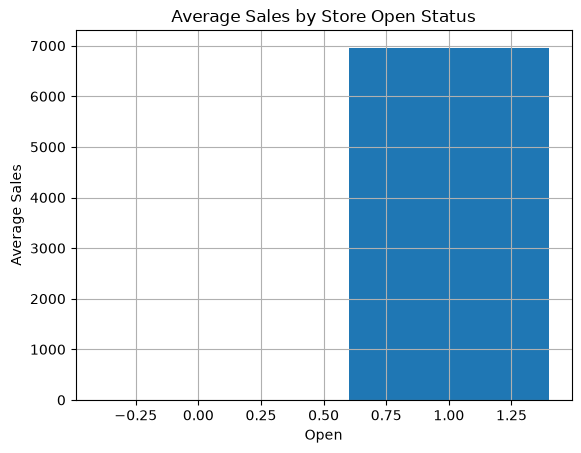

In [46]:
plt.bar(avg_sales_open.index, avg_sales_open.values)

plt.title("Average Sales by Store Open Status")
plt.xlabel("Open")
plt.ylabel("Average Sales")
plt.grid(True)

plt.show()

In [47]:
train["StateHoliday"].value_counts()

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [48]:
train.groupby("StateHoliday")["Sales"].mean()

StateHoliday
0    5733.530624
0    5980.279717
a     290.735686
b     214.311510
c     168.733171
Name: Sales, dtype: float64

In [49]:
# Convert all StateHoliday values to string so '0' and 0 are treated consistently
train["StateHoliday"] = train["StateHoliday"].astype(str)

In [50]:
train["StateHoliday"].value_counts()

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [51]:
avg_sales_holiday = train.groupby("StateHoliday")["Sales"].mean()
avg_sales_holiday

StateHoliday
0    5947.483893
a     290.735686
b     214.311510
c     168.733171
Name: Sales, dtype: float64

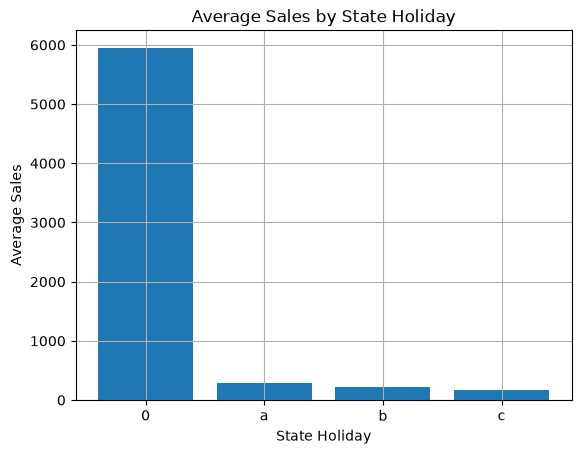

In [52]:
plt.bar(avg_sales_holiday.index, avg_sales_holiday.values)

plt.title("Average Sales by State Holiday")
plt.xlabel("State Holiday")
plt.ylabel("Average Sales")
plt.grid(True)

plt.show()

“StateHoliday categories પ્રમાણે Average Salesમાં મોટો difference જોવા મળે છે. No State Holiday (0) દરમિયાન Average Sales સૌથી વધારે છે, જ્યારે holiday categories (a, b, c) દરમિયાન observed Average Sales ખૂબ ઓછું છે. આ difference store closing status જેવા factorsથી પણ પ્રભાવિત થઈ શકે છે.”

In [53]:
avg_sales_store = train.groupby("Store")["Sales"].mean()

In [54]:
avg_sales_store.head()

Store
1    3945.704883
2    4122.991507
3    5741.253715
4    8021.769639
5    3867.110403
Name: Sales, dtype: float64

In [55]:
avg_sales_store.nlargest(10)

Store
262     20718.515924
817     18108.139066
562     17969.556263
1114    17200.196391
251     15814.087049
842     15242.114776
513     15129.942675
788     14949.194268
733     14933.288747
383     14320.466030
Name: Sales, dtype: float64

આથી ખબર પડે છે કે બધા storesની Average Sales એકસરખી નથી. કેટલાક storesમાં average sales ઘણી વધારે છે.


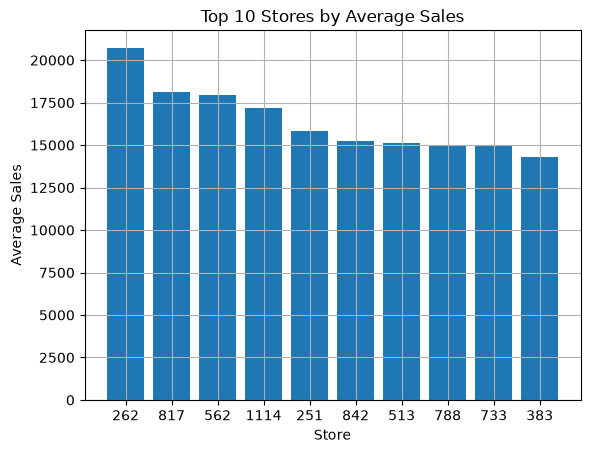

In [56]:
top_10_stores = avg_sales_store.nlargest(10)
plt.bar(top_10_stores.index.astype(str), top_10_stores.values)

plt.title("Top 10 Stores by Average Sales")
plt.xlabel("Store")
plt.ylabel("Average Sales")
plt.grid(True)

plt.show()

In [57]:
bottom_10_stores = avg_sales_store.nsmallest(10)
bottom_10_stores

Store
307    2244.503185
543    2313.468153
198    2407.933121
208    2443.791932
841    2461.395966
254    2485.839703
972    2550.559448
794    2553.475584
219    2591.467091
210    2641.309979
Name: Sales, dtype: float64

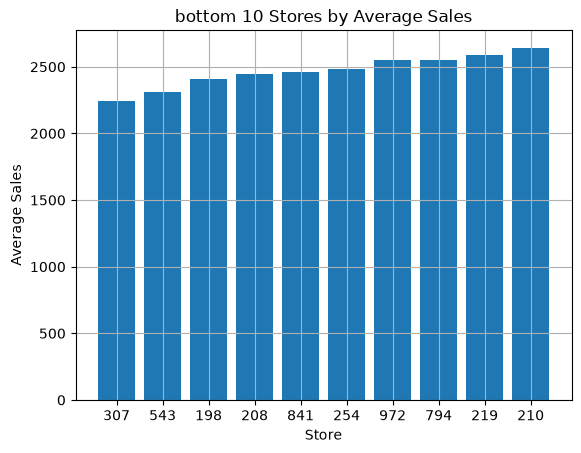

In [58]:
plt.bar(bottom_10_stores.index.astype(str), bottom_10_stores.values)

plt.title("bottom 10 Stores by Average Sales")
plt.xlabel("Store")
plt.ylabel("Average Sales")
plt.grid(True)

plt.show()

“Store-wise Average Salesમાં નોંધપાત્ર variation જોવા મળે છે. કેટલાક storesમાં Average Sales ઘણી વધારે છે, જ્યારે કેટલાક storesમાં ઓછી છે. તેથી Store Sales prediction માટે potentially important feature હોઈ શકે છે.”

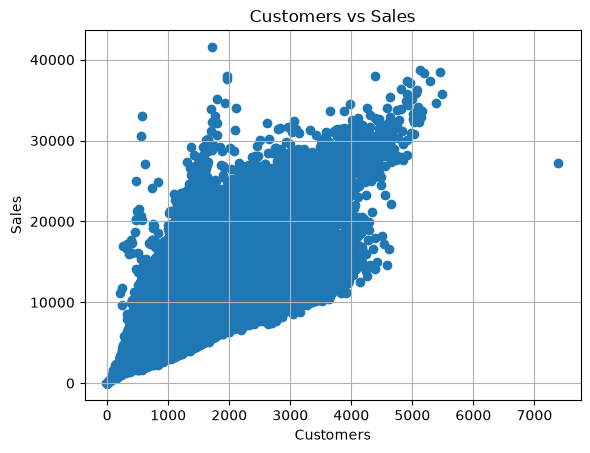

In [59]:
plt.scatter(train["Customers"], train["Sales"])

plt.title("Customers vs Sales")
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

“Customers વધે તેમ Sales પણ સામાન્ય રીતે વધે છે. Customers અને Sales વચ્ચે positive relationship જોવા મળે છે. જોકે કેટલાક observationsમાં સમાન Customers હોવા છતાં Sales અલગ છે, તેથી Sales પર અન્ય factors પણ અસર કરે છે. Customers Sales prediction માટે useful feature હોઈ શકે છે.”

In [60]:
train.select_dtypes(include="number")

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
0,1,5,5263,555,1,1,1
1,2,5,6064,625,1,1,1
2,3,5,8314,821,1,1,1
3,4,5,13995,1498,1,1,1
4,5,5,4822,559,1,1,1
...,...,...,...,...,...,...,...
1017204,1111,2,0,0,0,0,1
1017205,1112,2,0,0,0,0,1
1017206,1113,2,0,0,0,0,1
1017207,1114,2,0,0,0,0,1


In [61]:
train.select_dtypes(include="number").corr()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
Store,1.000000,-0.000008,0.005126,0.024325,-0.000047,0.000058,0.000641
DayOfWeek,-0.000008,1.000000,-0.462125,-0.386445,-0.528963,-0.392925,-0.205388
Sales,0.005126,-0.462125,1.000000,0.894711,0.678472,0.452345,0.085124
Customers,0.024325,-0.386445,0.894711,1.000000,0.616768,0.316169,0.071568
Open,-0.000047,-0.528963,0.678472,0.616768,1.000000,0.295042,0.086171
Promo,0.000058,-0.392925,0.452345,0.316169,0.295042,1.000000,0.067483
SchoolHoliday,0.000641,-0.205388,0.085124,0.071568,0.086171,0.067483,1.000000


“Correlation analysis મુજબ Customers અને Sales વચ્ચે strong positive relationship (0.8947) જોવા મળે છે. Open અને Sales વચ્ચે પણ positive relationship (0.6785) છે. Promo અને Sales વચ્ચે moderate positive relationship (0.4523) જોવા મળે છે. SchoolHoliday અને Sales વચ્ચે ખૂબ weak relationship છે. Storeનું overall linear correlation Sales સાથે લગભગ zero છે.”  aama apne sales hi column ne jovi chavi

Heatmapમાં correlation matrixને રંગો દ્વારા visually બતાવી શકીશું, એટલે કયા features વચ્ચે relationship વધારે/ઓછું છે તે ઝડપથી સમજાશે.

In [62]:
correlation = train.select_dtypes(include="number").corr()

In [63]:
import seaborn as sns

<Axes: >

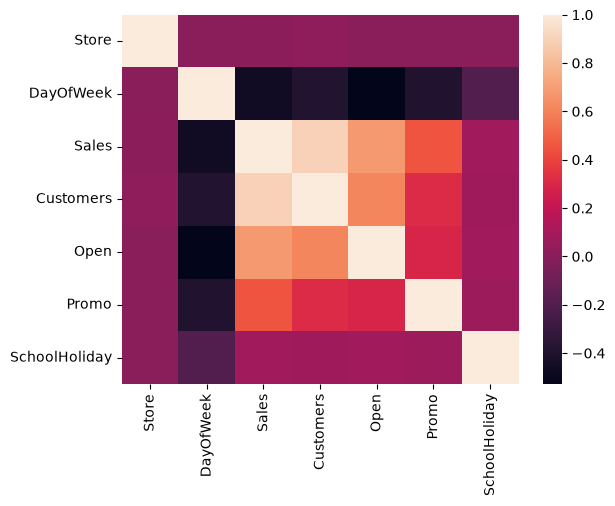

In [64]:
sns.heatmap(correlation)

Correlation heatmap પરથી જોવા મળે છે કે Customers અને Sales વચ્ચે strong positive relationship છે. Open અને Sales વચ્ચે પણ strong positive relationship છે, જ્યારે Promo અને Sales વચ્ચે moderate positive relationship છે. SchoolHoliday અને Sales વચ્ચે very weak relationship જોવા મળે છે. Heatmap numerical features વચ્ચેના relationshipsને visually સમજવામાં મદદ કરે છે.”

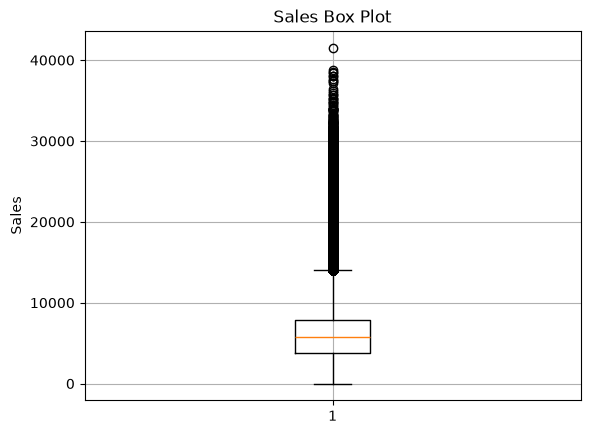

In [65]:
plt.boxplot(train["Sales"])
plt.title("Sales Box Plot")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Box Plot શું કહે છે?

આપણા graphમાં વચ્ચે જે box છે, એ બતાવે છે કે Salesની મોટાભાગની normal values ક્યાં છે.

આ graphમાં:

Box લગભગ 4,000 થી 8,000 વચ્ચે છે → એટલે ઘણી Sales values અહીં છે.
Boxની ઉપર એક line લગભગ 14,000 સુધી જાય છે.
14,000 પછીના ઘણા બધા dots દેખાય છે → આ values સામાન્ય range કરતાં ઘણી મોટી છે. તેમને potential outliers કહેવામાં આવે છે.
કેટલાક dots 30,000, 35,000, 40,000+ સુધી છે.

## EDA Key Insights

1. Sales distribution જમણી તરફ ઝુકાવ જોવા મળે છે. મોટાભાગની Sales values lower rangeમાં છે, જ્યારે કેટલીક observations માં Sales ખૂબ વધારે જોવા મળે છે.

2. Datasetમાં Sales = 0 વાળા ઘણા records છે. આ records મુખ્યત્વે Store બંધ હોવાના કારણે છે. Open = 0 હોય ત્યારે Sales 0 જોવા મળે છે.

3. અલગ-અલગ દિવસોમાં Average Sales અલગ જોવા મળે છે. Mondayનું Average Sales સૌથી વધારે છે, જ્યારે Sundayનું ખૂબ ઓછું છે. Sundayમાં ઘણા stores બંધ હોવું તેનું એક કારણ હોઈ શકે છે.

4. Promo = 1 વાળા દિવસોમાં Average Sales, Promo = 0 કરતા વધારે જોવા મળે છે. આ datasetમાં Promo અને Sales વચ્ચે positive observed relationship છે, પરંતુ તે cancustion સાબિત કરતું નથી.

5. Customers અને Sales વચ્ચે strong positive relationship જોવા મળે છે. Customers વધે તેમ Sales પણ સામાન્ય રીતે વધે છે. તેથી Customers Sales prediction માટે useful feature હોઈ શકે છે.

6. અલગ-અલગ Storesમાં Average Salesમાં ઘણો variation જોવા મળે છે. કેટલાક Storesમાં Sales વધારે છે, જ્યારે કેટલાક Storesમાં ઓછી છે.

7. StateHolidayની અલગ categories પ્રમાણે Average Salesમાં મોટો difference જોવા મળે છે. Holiday categoriesમાં Average Sales સામાન્ય રીતે ઓછી જોવા મળે છે, જે Store closing status જેવા factorsથી પણ પ્રભાવિત થઈ શકે છે.

8. Salesના Box Plotમાં ઘણા potential outliers જોવા મળે છે. કેટલીક Sales values ખૂબ વધારે છે, પરંતુ આ values genuine business observations હોઈ શકે છે. તેથી હાલમાં આ values remove કરવામાં આવશે નહીં.

9. Correlation analysis મુજબ Customers અને Sales વચ્ચે સૌથી strong positive linear relationship જોવા મળે છે. Open અને Promo પણ Sales સાથે positive relationship ધરાવે છે.

### EDA Conclusion

EDA દરમિયાન Sales, Stores, Customers, Promo, રજાઓ અને Store બંધ કે ચાલુ હોવા જેવી બાબતોનો અભ્યાસ કર્યો. વિવિધ લક્ષણો અને Sales વચ્ચે અલગ-અલગ પ્રકારના સંબંધો જોવા મળ્યા. આ પરિણામો આગળના Data Cleaning, Feature Engineering અને Machine Learningના તબક્કામાં ઉપયોગી રહેશે.

## Step 3 — Data Cleaning


In [66]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [68]:
train.duplicated().sum()

np.int64(0)

In [73]:
train.dtypes

Store                     int64
DayOfWeek                 int64
Date             datetime64[us]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday                str
SchoolHoliday             int64
dtype: object

In [74]:
train["Date"].min(),train["Date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [75]:
train["StateHoliday"].value_counts()

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [76]:
train["StateHoliday"].unique()

<StringArray>
['0', 'a', 'b', 'c']
Length: 4, dtype: str

In [78]:
train["Sales"].min(),train["Sales"].max()

(np.int64(0), np.int64(41551))

In [79]:
train["Customers"].min(),train["Customers"].max()

(np.int64(0), np.int64(7388))

In [86]:
train["Open"].unique()

array([1, 0])

In [87]:
train["Promo"].unique()

array([1, 0])

In [90]:
train["DayOfWeek"].min(), train["DayOfWeek"].max()

(np.int64(1), np.int64(7))

In [91]:
train.shape

(1017209, 9)

In [95]:
train.isnull().sum().sum()

np.int64(0)